# Exploratory Data Analysis: Business Licences
This notebook explores the business licences dataset
We will look at descriptive statistics, distributions, and time-series trends


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
# Load the dataset
df = pd.read_csv('../../data/staging/business_licences_transformed_20260320.csv')

# Display the first few rows to understand the structure
df.head()


C:\Users\Chris\AppData\Local\Temp\ipykernel_29464\3651130973.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/staging/business_licences_transformed_20260320.csv')


,folder_year,licence_rsn,licencenumber,licence_revision_number,business_name,business_trade_name,status,issued_date,expired_date,businesstype,...,city,province,country,postal_code,local_area,numberofemployees,fee_paid,extractdate,latitude,longitude
0,24,4495242,24-113627,10,Women Working With Women Society,mis'cel'la'ny (Miscellany Finds),Issued,2023-11-24 18:33:33+00:00,2024-12-31 00:00:00+00:00,Association or Society,...,Vancouver,BC,CA,V5L 3X1,Grandview-Woodland,1,NaN,2026-03-01T10:34:03+00:00,49.275234,-123.069911
1,24,4495246,24-113631,10,South Vancouver Family Place Society,NaN,Issued,2024-02-09 18:50:46+00:00,2024-12-31 00:00:00+00:00,Association or Society,...,Vancouver,BC,CA,V5P 4Y2,Victoria-Fraserview,20,NaN,2026-03-01T10:34:03+00:00,49.214175,-123.058683
2,24,4495252,24-113637,10,Urban Native Youth Association,NaN,Issued,2023-11-23 17:35:44+00:00,2024-12-31 00:00:00+00:00,Association or Society,...,Vancouver,BC,CA,V5L 1S6,Grandview-Woodland,50,NaN,2026-03-01T10:34:03+00:00,49.280950,-123.071814
3,24,4495254,24-113639,10,Canadian Mental Health Association Vancouver-F...,NaN,Issued,2023-11-23 18:34:42+00:00,2024-12-31 00:00:00+00:00,Association or Society,...,Vancouver,BC,CA,V5T 4L6,Mount Pleasant,30,NaN,2026-03-01T10:34:03+00:00,49.263485,-123.103189
4,24,4495258,24-113643,10,Vancouver Area Network Of Drug Users,NaN,Issued,2023-11-22 20:32:02+00:00,2024-12-31 00:00:00+00:00,Association or Society,...,Vancouver,BC,CA,V6A 1P4,Strathcona,7,NaN,2026-03-01T10:34:03+00:00,49.280963,-123.095796


In [3]:
# Descriptive Statistics
# We select numeric columns to calculate mean, median, and standard deviation
numeric_cols = ['numberofemployees', 'fee_paid']

print("Descriptive Statistics for Numeric Columns:")
display(df[numeric_cols].describe())

print("\nMedian values:")
display(df[numeric_cols].median())


Descriptive Statistics for Numeric Columns:


,numberofemployees,fee_paid
count,169579.000000,119550.000000
mean,10.729577,523.334075
std,75.791949,1120.900942
min,0.000000,2.000000
25%,0.000000,243.000000
50%,1.000000,277.000000
75%,5.000000,405.000000
max,5876.000000,63722.000000



Median values:


numberofemployees      1.0
fee_paid             277.0
dtype: float64

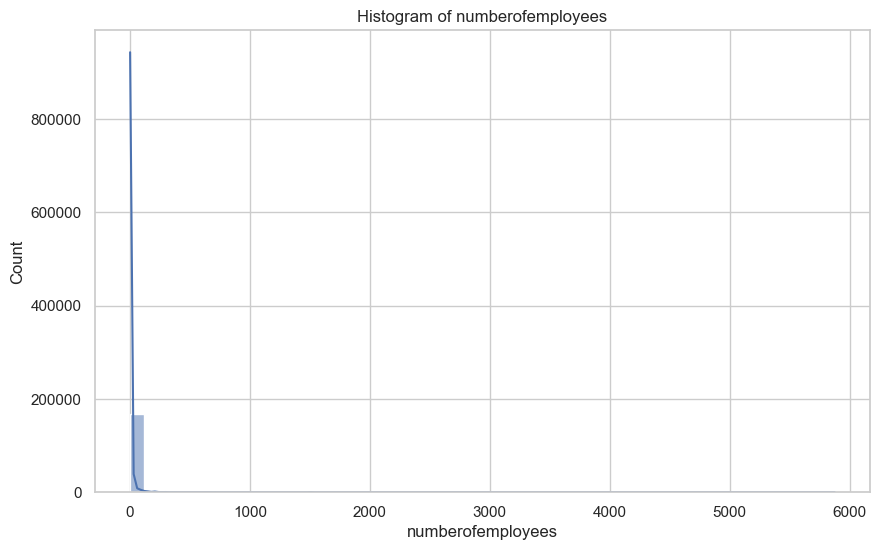

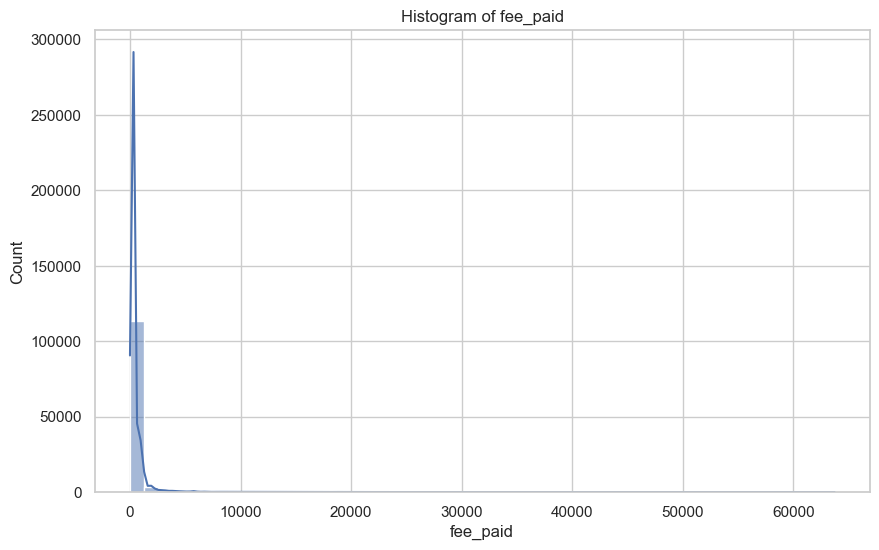

In [ ]:
# Histograms to detect outliers and see distributions
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

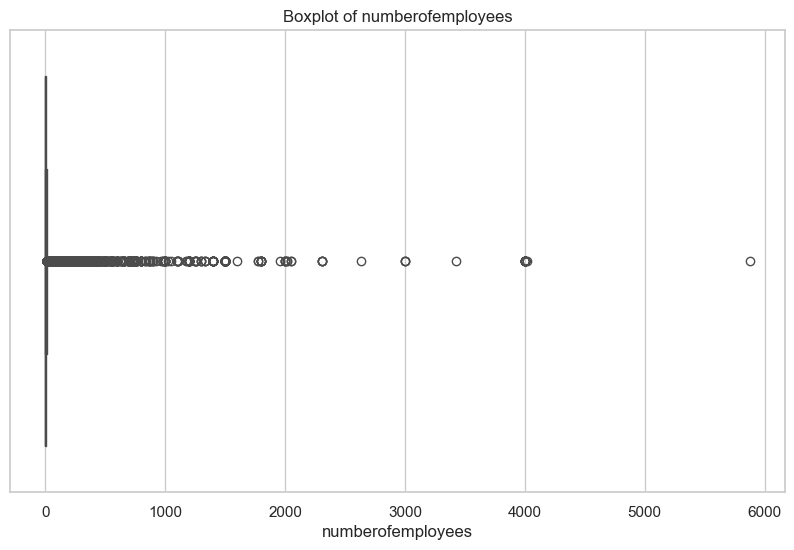

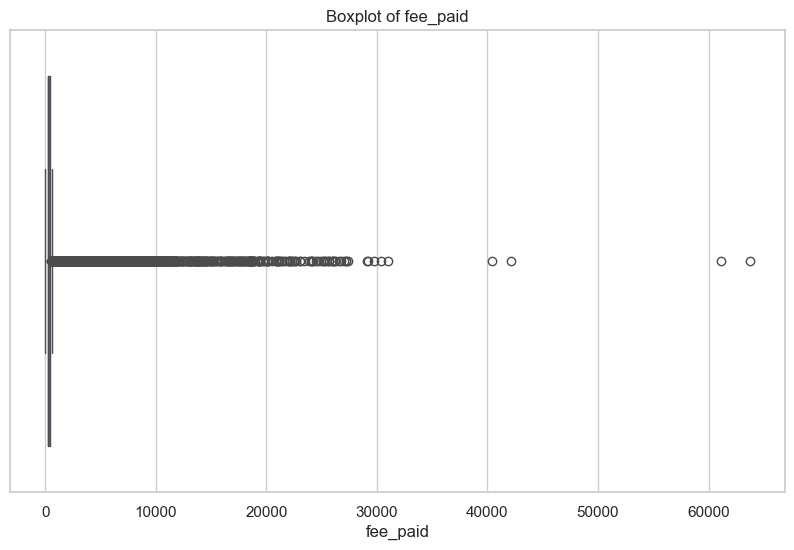

In [5]:
# Boxplots to detect outliers
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.show()


C:\Users\Chris\AppData\Local\Temp\ipykernel_29464\4045423433.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['issued_year_month'] = df['issued_date'].dt.to_period('M')


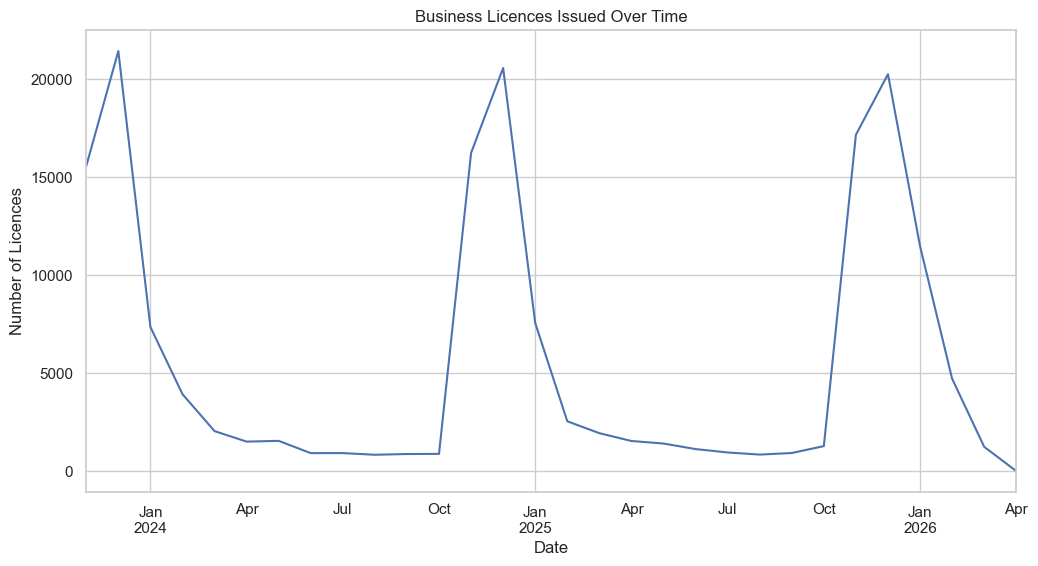

In [ ]:
# Time-series analysis
# Convert issued_date to datetime
df['issued_date'] = pd.to_datetime(df['issued_date'], errors='coerce')

# Extract year and month for trend analysis
df['issued_year_month'] = df['issued_date'].dt.to_period('M')

# Count licenses issued per month
monthly_counts = df.groupby('issued_year_month').size()

plt.figure(figsize=(12, 6))
monthly_counts.plot()
plt.title('Business Licences Issued Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Licences')
plt.show()

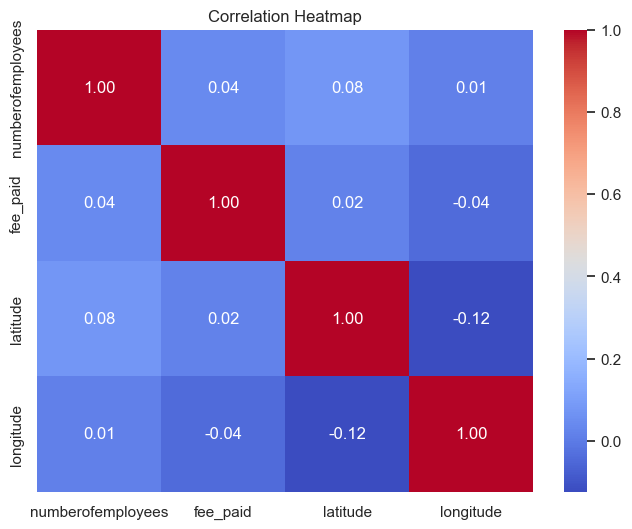

In [7]:
# Correlation heatmap
# Calculate correlation matrix for numeric features
corr_matrix = df[['numberofemployees', 'fee_paid', 'latitude', 'longitude']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
